,metric,value
0,JF,5.000000e+01
1,RDI,1.750000e+01
2,HF,1.000000e+01
3,A,5.850000e+00
4,Lb_m,1.440000e+00
5,Lc_m,5.760000e+00
6,Ltot_m,7.200000e+00
7,Q_kg,1.539537e+02
8,V0_m3,3.109600e+02
9,q_kg_m3,4.950918e-01


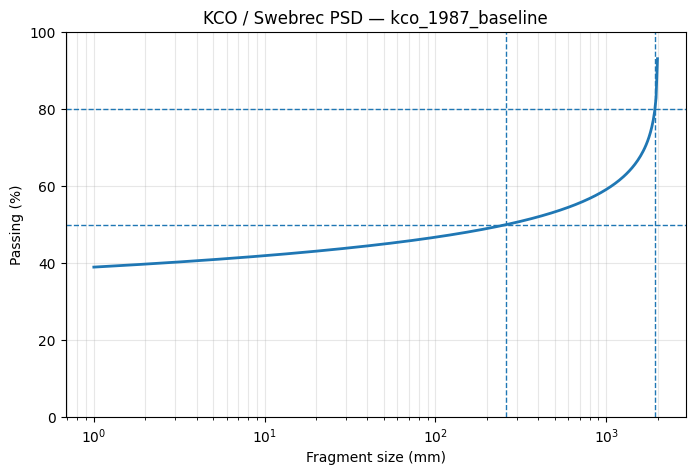

In [1]:
# ============================================================
# KCO / Swebrec fragmentation model
# Baseline: Cunningham (1987) + KCO(Swebrec)
# Optional branches:
#   - use_ouchterlony_b = True
#   - use_spathis_correction = True
# ============================================================

from __future__ import annotations

import math
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Config
# ------------------------------------------------------------

MODEL_VARIANT = "kco_1987_baseline"
# allowed:
# "kco_1987_baseline"
# "kco_ouchterlony_b"
# "kco_spathis_variant"

use_ouchterlony_b = MODEL_VARIANT == "kco_ouchterlony_b"
use_spathis_correction = MODEL_VARIANT == "kco_spathis_variant"


# ------------------------------------------------------------
# Inputs
# ------------------------------------------------------------

@dataclass
class KCOInputs:
    # Geometry
    burden_m: float
    spacing_m: float
    bench_height_m: float
    hole_diameter_mm: float
    subdrill_m: float
    stemming_m: float

    # Explosive
    explosive_density_kg_m3: float
    explosive_rws_pct: float   # RWS relative to ANFO (%)

    # Hole quality / geometry realism
    drilling_deviation_m: float   # W
    in_situ_block_size_mm: float | None = None

    # Rock / blastability inputs
    rock_density_t_m3: float = 2.7
    rmd: float = 20.0
    jps: float = 20.0
    jpa: float = 30.0

    # Hardness inputs:
    # Use one of:
    youngs_modulus_gpa: float | None = None
    ucs_mpa: float | None = None
    hf_override: float | None = None

    # Optional charge split overrides
    bottom_charge_length_m: float | None = None   # Lb
    column_charge_length_m: float | None = None   # Lc

    # Optional Ouchterlony burden reference
    burden_ref_m: float | None = None


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def safe_ln(x: float, eps: float = 1e-12) -> float:
    return math.log(max(x, eps))

def clamp(x: float, lo: float, hi: float) -> float:
    return max(lo, min(hi, x))

def gamma_func(x: float) -> float:
    return math.gamma(x)


# ------------------------------------------------------------
# Blastability terms
# ------------------------------------------------------------

def calc_jf(jps: float, jpa: float) -> float:
    return jps + jpa

def calc_rdi(rock_density_t_m3: float) -> float:
    return 25.0 * rock_density_t_m3 - 50.0

def calc_hf(
    youngs_modulus_gpa: float | None,
    ucs_mpa: float | None,
    hf_override: float | None = None,
) -> float:
    if hf_override is not None:
        return hf_override

    if youngs_modulus_gpa is not None:
        if youngs_modulus_gpa < 50.0:
            return youngs_modulus_gpa / 3.0
        if ucs_mpa is not None:
            return ucs_mpa / 5.0

    if ucs_mpa is not None:
        return ucs_mpa / 5.0

    raise ValueError(
        "Need one of: hf_override, youngs_modulus_gpa, or ucs_mpa"
    )

def calc_blastability_A(
    rmd: float,
    jps: float,
    jpa: float,
    rock_density_t_m3: float,
    youngs_modulus_gpa: float | None,
    ucs_mpa: float | None,
    hf_override: float | None,
) -> Dict[str, float]:
    jf = calc_jf(jps, jpa)
    rdi = calc_rdi(rock_density_t_m3)
    hf = calc_hf(youngs_modulus_gpa, ucs_mpa, hf_override)
    A = 0.06 * (rmd + jf + rdi + hf)
    return {
        "JF": jf,
        "RDI": rdi,
        "HF": hf,
        "A": A,
    }


# ------------------------------------------------------------
# Charge geometry
# ------------------------------------------------------------

def calc_charge_lengths(inp: KCOInputs) -> Dict[str, float]:
    total_hole_length_m = inp.bench_height_m + inp.subdrill_m
    charged_length_m = total_hole_length_m - inp.stemming_m

    if charged_length_m <= 0:
        raise ValueError("Charged length must be > 0. Check stemming/subdrill/bench height.")

    # If user supplied Lb/Lc, honour them
    if inp.bottom_charge_length_m is not None or inp.column_charge_length_m is not None:
        lb = inp.bottom_charge_length_m or 0.0
        lc = inp.column_charge_length_m or 0.0
        ltot = lb + lc
        if ltot <= 0:
            raise ValueError("Lb + Lc must be > 0.")
        return {
            "total_hole_length_m": total_hole_length_m,
            "charged_length_m": charged_length_m,
            "Lb_m": lb,
            "Lc_m": lc,
            "Ltot_m": ltot,
        }

    # Default practical assumption:
    # use a short bottom charge deck equal to ~20% of charge length,
    # remainder treated as column charge
    lb = 0.20 * charged_length_m
    lc = charged_length_m - lb
    ltot = lb + lc

    return {
        "total_hole_length_m": total_hole_length_m,
        "charged_length_m": charged_length_m,
        "Lb_m": lb,
        "Lc_m": lc,
        "Ltot_m": ltot,
    }


# ------------------------------------------------------------
# Explosive mass and specific charge
# ------------------------------------------------------------

def calc_explosive_terms(inp: KCOInputs, ltot_m: float) -> Dict[str, float]:
    hole_diameter_m = inp.hole_diameter_mm / 1000.0
    hole_radius_m = hole_diameter_m / 2.0
    hole_area_m2 = math.pi * hole_radius_m**2

    Q_kg = hole_area_m2 * ltot_m * inp.explosive_density_kg_m3
    V0_m3 = inp.burden_m * inp.spacing_m * inp.bench_height_m
    q_kg_m3 = Q_kg / V0_m3

    return {
        "hole_area_m2": hole_area_m2,
        "Q_kg": Q_kg,
        "V0_m3": V0_m3,
        "q_kg_m3": q_kg_m3,
    }


# ------------------------------------------------------------
# Cunningham 1987 x50
# x50 = A * Q^(1/6) * (115/RWS)^(19/30) / q^0.8   [cm]
# then convert to mm
# ------------------------------------------------------------

def calc_x50_mm(A: float, Q_kg: float, rws_pct: float, q_kg_m3: float) -> float:
    if Q_kg <= 0 or rws_pct <= 0 or q_kg_m3 <= 0:
        raise ValueError("Q, RWS and q must be > 0.")

    x50_cm = A * (Q_kg ** (1.0 / 6.0)) * ((115.0 / rws_pct) ** (19.0 / 30.0)) / (q_kg_m3 ** 0.8)
    x50_mm = 10.0 * x50_cm
    return x50_mm


# ------------------------------------------------------------
# Optional Spathis median/mean correction branch
# Applies to legacy interpretations only; not baseline 1987
# ------------------------------------------------------------

def calc_g_of_n(n: float) -> float:
    if n <= 0:
        raise ValueError("n must be > 0 for g(n).")
    return (math.log(2.0) ** (1.0 / n)) / gamma_func(1.0 + 1.0 / n)

def apply_spathis_correction(x_unadjusted_mm: float, n: float) -> float:
    return x_unadjusted_mm * calc_g_of_n(n)


# ------------------------------------------------------------
# Revised Cunningham 1987 uniformity term
# n = (2.2 - 14 B/d) * (1 - W/B) * sqrt((1 + S/B)/2)
#     * (1 - |Lb - Lc|/Ltot) * (0.1 + 0.1*Ltot/H)
#
# B, S, W, H, L in m
# d in mm
# ------------------------------------------------------------

def calc_uniformity_n(
    burden_m: float,
    spacing_m: float,
    hole_diameter_mm: float,
    drilling_deviation_m: float,
    bench_height_m: float,
    lb_m: float,
    lc_m: float,
    ltot_m: float,
) -> float:
    if burden_m <= 0 or spacing_m <= 0 or hole_diameter_mm <= 0 or bench_height_m <= 0 or ltot_m <= 0:
        raise ValueError("Geometry inputs must be > 0.")

    term1 = 2.2 - 14.0 * burden_m / hole_diameter_mm
    term2 = 1.0 - drilling_deviation_m / burden_m
    term3 = math.sqrt((1.0 + spacing_m / burden_m) / 2.0)
    term4 = 1.0 - abs(lb_m - lc_m) / ltot_m
    term5 = 0.1 + 0.1 * ltot_m / bench_height_m

    n = term1 * term2 * term3 * term4 * term5
    return max(n, 1e-6)


# ------------------------------------------------------------
# KCO xmax and b
# Early KCO:
#   xmax = min(in_situ_block_size, B, S) in mm
#   b = 2 ln(2) ln(xmax/x50) n
#
# Optional later refinement:
#   b = 0.5 * x50^0.25 * ln(xmax/x50)
# or burden-adjusted:
#   b = 0.4 * (Bref/B)^0.25 * x50^0.25 * ln(xmax/x50)
# ------------------------------------------------------------

def calc_xmax_mm(inp: KCOInputs) -> float:
    geom_cap_mm = 1000.0 * min(inp.burden_m, inp.spacing_m)
    if inp.in_situ_block_size_mm is None:
        return geom_cap_mm
    return min(inp.in_situ_block_size_mm, geom_cap_mm)

def calc_b_kco_baseline(x50_mm: float, xmax_mm: float, n: float) -> float:
    if xmax_mm <= x50_mm:
        raise ValueError(f"xmax must exceed x50. Got xmax={xmax_mm:.2f}, x50={x50_mm:.2f}")
    return 2.0 * math.log(2.0) * math.log(xmax_mm / x50_mm) * n

def calc_b_ouchterlony(x50_mm: float, xmax_mm: float, burden_m: float, burden_ref_m: float | None) -> float:
    if xmax_mm <= x50_mm:
        raise ValueError(f"xmax must exceed x50. Got xmax={xmax_mm:.2f}, x50={x50_mm:.2f}")
    log_term = math.log(xmax_mm / x50_mm)

    if burden_ref_m is None or burden_ref_m <= 0:
        return 0.5 * (x50_mm ** 0.25) * log_term

    return 0.4 * ((burden_ref_m / burden_m) ** 0.25) * (x50_mm ** 0.25) * log_term


# ------------------------------------------------------------
# Swebrec CDF
# P(x) = 1 / (1 + ( ln(xmax/x) / ln(xmax/x50) )^b )
# ------------------------------------------------------------

def swebrec_cdf(x_mm: np.ndarray | float, x50_mm: float, xmax_mm: float, b: float) -> np.ndarray:
    x = np.asarray(x_mm, dtype=float)

    if x50_mm <= 0 or xmax_mm <= 0 or b <= 0:
        raise ValueError("x50, xmax and b must be > 0.")
    if xmax_mm <= x50_mm:
        raise ValueError("xmax must exceed x50.")

    x = np.clip(x, 1e-9, xmax_mm * (1.0 - 1e-12))
    denom = math.log(xmax_mm / x50_mm)

    if denom <= 0:
        raise ValueError("ln(xmax/x50) must be > 0.")

    ratio = np.log(xmax_mm / x) / denom
    ratio = np.clip(ratio, 0.0, None)

    p = 1.0 / (1.0 + np.power(ratio, b))
    return np.clip(p, 0.0, 1.0)


# ------------------------------------------------------------
# Quantile helper by inversion on grid
# ------------------------------------------------------------

def estimate_quantile_mm(x_grid_mm: np.ndarray, cdf: np.ndarray, target_p: float) -> float:
    target_p = clamp(target_p, 0.0, 1.0)
    return float(np.interp(target_p, cdf, x_grid_mm))


# ------------------------------------------------------------
# Full model runner
# ------------------------------------------------------------

def run_kco_model(inp: KCOInputs) -> Dict[str, float | pd.DataFrame]:
    blastability = calc_blastability_A(
        rmd=inp.rmd,
        jps=inp.jps,
        jpa=inp.jpa,
        rock_density_t_m3=inp.rock_density_t_m3,
        youngs_modulus_gpa=inp.youngs_modulus_gpa,
        ucs_mpa=inp.ucs_mpa,
        hf_override=inp.hf_override,
    )

    lengths = calc_charge_lengths(inp)

    expl = calc_explosive_terms(inp, lengths["Ltot_m"])

    n = calc_uniformity_n(
        burden_m=inp.burden_m,
        spacing_m=inp.spacing_m,
        hole_diameter_mm=inp.hole_diameter_mm,
        drilling_deviation_m=inp.drilling_deviation_m,
        bench_height_m=inp.bench_height_m,
        lb_m=lengths["Lb_m"],
        lc_m=lengths["Lc_m"],
        ltot_m=lengths["Ltot_m"],
    )

    x50_mm = calc_x50_mm(
        A=blastability["A"],
        Q_kg=expl["Q_kg"],
        rws_pct=inp.explosive_rws_pct,
        q_kg_m3=expl["q_kg_m3"],
    )

    if use_spathis_correction:
        x50_mm = apply_spathis_correction(x50_mm, n)

    xmax_mm = calc_xmax_mm(inp)

    if use_ouchterlony_b:
        b = calc_b_ouchterlony(
            x50_mm=x50_mm,
            xmax_mm=xmax_mm,
            burden_m=inp.burden_m,
            burden_ref_m=inp.burden_ref_m,
        )
    else:
        b = calc_b_kco_baseline(
            x50_mm=x50_mm,
            xmax_mm=xmax_mm,
            n=n,
        )

    if b <= 0:
        raise ValueError(f"Computed b <= 0 ({b:.4f}). Check inputs.")

    # Build PSD grid
    x_grid_mm = np.geomspace(1.0, max(1.0, xmax_mm * 0.999), 400)
    p_pass = swebrec_cdf(x_grid_mm, x50_mm=x50_mm, xmax_mm=xmax_mm, b=b)

    psd_df = pd.DataFrame({
        "size_mm": x_grid_mm,
        "passing_frac": p_pass,
        "passing_pct": 100.0 * p_pass,
        "retained_frac": 1.0 - p_pass,
        "retained_pct": 100.0 * (1.0 - p_pass),
    })

    x20 = estimate_quantile_mm(x_grid_mm, p_pass, 0.20)
    x50 = estimate_quantile_mm(x_grid_mm, p_pass, 0.50)
    x80 = estimate_quantile_mm(x_grid_mm, p_pass, 0.80)
    x90 = estimate_quantile_mm(x_grid_mm, p_pass, 0.90)

    out = {
        **blastability,
        **lengths,
        **expl,
        "n": n,
        "g_n": calc_g_of_n(n),
        "x50_mm": x50_mm,
        "xmax_mm": xmax_mm,
        "b": b,
        "x20_mm": x20,
        "x80_mm": x80,
        "x90_mm": x90,
        "psd_df": psd_df,
    }
    return out


# ------------------------------------------------------------
# Example inputs
# ------------------------------------------------------------

inp = KCOInputs(
    burden_m=5.2,
    spacing_m=5.2 * 1.15,
    bench_height_m=10.0,
    hole_diameter_mm=165.0,
    subdrill_m=1.2,
    stemming_m=4.0,
    explosive_density_kg_m3=1000.0,
    explosive_rws_pct=100.0,
    drilling_deviation_m=0.2,
    in_situ_block_size_mm=2000.0,
    rock_density_t_m3=2.7,
    rmd=20.0,
    jps=20.0,
    jpa=30.0,
    youngs_modulus_gpa=30.0,   # HF = E/3 when E < 50 GPa
    ucs_mpa=None,
    hf_override=None,
    bottom_charge_length_m=None,
    column_charge_length_m=None,
    burden_ref_m=None,
)

result = run_kco_model(inp)

# Debug print
debug_keys = [
    "JF", "RDI", "HF", "A",
    "Lb_m", "Lc_m", "Ltot_m",
    "Q_kg", "V0_m3", "q_kg_m3",
    "n", "g_n",
    "x50_mm", "xmax_mm", "b",
    "x20_mm", "x80_mm", "x90_mm",
]
debug_df = pd.DataFrame({
    "metric": debug_keys,
    "value": [result[k] for k in debug_keys],
})
display(debug_df)

# Plot PSD
psd_df = result["psd_df"]

plt.figure(figsize=(8, 5))
plt.semilogx(psd_df["size_mm"], psd_df["passing_pct"], linewidth=2)
plt.axvline(result["x50_mm"], linestyle="--", linewidth=1)
plt.axvline(result["x80_mm"], linestyle="--", linewidth=1)
plt.axhline(50, linestyle="--", linewidth=1)
plt.axhline(80, linestyle="--", linewidth=1)
plt.xlabel("Fragment size (mm)")
plt.ylabel("Passing (%)")
plt.title(f"KCO / Swebrec PSD — {MODEL_VARIANT}")
plt.ylim(0, 100)
plt.grid(True, which="both", alpha=0.3)
plt.show()
